# KLF1 — track profiles at the 3 CRISPR-validated enhancers

Companion to `epinformerseq_KLF1_screening.ipynb`. There we *ranked* the 82 candidate KLF1 CREs by EPInformer-seq's scalar enhancer-activity output. Here we look at **profile-shaped predictions** from five oracles at the three CRISPR-validated K562 enhancers and ask: do the open-chromatin / active-mark tracks the models predict agree with each other at these elements?

**The three Regulated CREs from EPCrispr (Nasser 2021, K562):**

| # | Element (chr19, 1-based) | Distance to TSS | Effect size | H3K27ac.RPM |
|---|---|---|---|---|
| 1 | 12,888,891–12,889,391 (proximal) | ~2 kb | −0.169 | 1.71 |
| 2 | 12,867,151–12,867,931 (mid)      | ~20 kb | −0.026 | 2.82 |
| 3 | 12,847,511–12,848,011 (distal)   | ~39 kb | −0.058 | 0.32 |

**Oracles compared (all K562):**

- **EPInformer-seq** — 256-bp window → scalar `Enhancer_H3K27ac_DNase` activity. Sliding-window (stride 16 bp) + per-base overlap averaging → bp-resolution profile.
- **ChromBPNet** — 2,114-bp → 1,000-bp central output. Tiled 60× across the locus for a 60-kb bp-resolution profile.
- **AlphaGenome** — 1 MB input → bp-resolution DNase + 128-bp H3K27ac. The only oracle here with K562 H3K27ac in training.
- **Borzoi** — 524-kb input → 6,144 × 32-bp bins. Single locus call.
- **Enformer** — 197-kb input → 896 × 128-bp bins. Single locus call.

**Training-set caveat (important):** Neither Enformer nor Borzoi's K562 training tracks include H3K27ac. We use CHIP:H3K4me1:K562 (canonical active-enhancer mark) as the histone-mark proxy for those two models. AlphaGenome and EPInformer-seq fill the H3K27ac gap directly.

**Runtime:** ~5-10 min on MPS / CUDA. Most of the time is AlphaGenome's first call (~3 min JAX JIT compile + ~3 min inference). The other four oracles together take <1 min.

## Setup

In [1]:
import os, warnings, json, time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
warnings.filterwarnings('ignore', message='.*padding="same".*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

import chorus
from chorus.utils import get_genome, extract_sequence

genome_path = get_genome('hg38')
print('hg38 genome:', genome_path)
print('chorus version:', getattr(chorus, '__version__', 'dev'))

hg38 genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa
chorus version: 0.4.0


## § 1. The 3 validated KLF1 enhancers

In [2]:
EPCRISPR_TSV = '../walkthroughs/CRISPR_valid_CREs/EPCrisprBenchmark_combined_data.training_K562.GRCh38.tsv.gz'
df = pd.read_csv(EPCRISPR_TSV, sep='\t')
klf1 = df[df['measuredGeneSymbol'] == 'KLF1'].copy()
klf1_pos = klf1[klf1['Regulated'] == True].copy().reset_index(drop=True)
klf1_pos['midpoint'] = (klf1_pos['chromStart'] + klf1_pos['chromEnd']) // 2
klf1_pos['width'] = klf1_pos['chromEnd'] - klf1_pos['chromStart']
klf1_pos = klf1_pos.sort_values('midpoint').reset_index(drop=True)
klf1_pos['label'] = ['distal', 'mid', 'proximal']

print(f'KLF1 candidate CREs : {len(klf1)}')
print(f'KLF1 Regulated      : {len(klf1_pos)}')
print()
display_cols = ['label', 'chrom', 'chromStart', 'chromEnd', 'midpoint', 'width',
                'distanceToTSS', 'EffectSize', 'H3K27ac.RPM']
klf1_pos[display_cols]

KLF1 candidate CREs : 82
KLF1 Regulated      : 3



,label,chrom,chromStart,chromEnd,midpoint,width,distanceToTSS,EffectSize,H3K27ac.RPM
0,distal,chr19,12847511,12848011,12847761,500,39441,-0.057784,0.317648
1,mid,chr19,12867151,12867931,12867541,780,19661,-0.026087,2.818881
2,proximal,chr19,12888891,12889391,12889141,500,1937,-0.169294,1.707113


## § 2. Locus geometry — one display window for all 3 enhancers

We center the display on the midpoint of the proximal+distal enhancers, take a 60-kb display window, and choose oracle input centers + windows so that all three enhancers are inside each oracle's *output* (predicted) interval.

In [3]:
CHROM         = 'chr19'
TSS           = 12_887_180
LOCUS_CENTER  = (klf1_pos['midpoint'].iloc[0] + klf1_pos['midpoint'].iloc[-1]) // 2  # ~12,868,451
DISPLAY_HALF  = 30_000
DISPLAY_START = LOCUS_CENTER - DISPLAY_HALF
DISPLAY_END   = LOCUS_CENTER + DISPLAY_HALF

# Oracle output-window math (centered on LOCUS_CENTER)
BORZOI_INPUT_LEN     = 524_288
BORZOI_OUTPUT_LEN    = 196_608
BORZOI_BIN           = 32
ENFORMER_INPUT_LEN   = 196_608
ENFORMER_OUTPUT_LEN  = 114_688
ENFORMER_BIN         = 128
EPI_WINDOW           = 256
EPI_STRIDE           = 16
CBP_INPUT_LEN        = 2_114

print(f'Display:  {CHROM}:{DISPLAY_START:,}-{DISPLAY_END:,}  ({DISPLAY_END-DISPLAY_START:,} bp)')
print(f'Center:   {LOCUS_CENTER:,}    TSS: {TSS:,}    \u0394to-center: {TSS-LOCUS_CENTER:+,} bp')
print()
for name, ilen, olen, b in [
    ('Enformer', ENFORMER_INPUT_LEN, ENFORMER_OUTPUT_LEN, ENFORMER_BIN),
    ('Borzoi',   BORZOI_INPUT_LEN,   BORZOI_OUTPUT_LEN,   BORZOI_BIN),
]:
    in_s, in_e = LOCUS_CENTER - ilen//2, LOCUS_CENTER + ilen//2
    out_s, out_e = LOCUS_CENTER - olen//2, LOCUS_CENTER + olen//2
    contained = (out_s <= DISPLAY_START) and (out_e >= DISPLAY_END)
    print(f'{name:9s}  input {ilen:>7,} bp [{in_s:,}-{in_e:,}]  output {olen:,} bp [{out_s:,}-{out_e:,}]  display\u2208output={contained}')
print()
n_epi_windows = (DISPLAY_END - DISPLAY_START - EPI_WINDOW) // EPI_STRIDE + 1
print(f'EPInformer-seq sliding: window={EPI_WINDOW}, stride={EPI_STRIDE} \u2192 {n_epi_windows:,} forward passes')

Display:  chr19:12,838,451-12,898,451  (60,000 bp)
Center:   12,868,451    TSS: 12,887,180    Δto-center: +18,729 bp

Enformer   input 196,608 bp [12,770,147-12,966,755]  output 114,688 bp [12,811,107-12,925,795]  display∈output=True
Borzoi     input 524,288 bp [12,606,307-13,130,595]  output 196,608 bp [12,770,147-12,966,755]  display∈output=True

EPInformer-seq sliding: window=256, stride=16 → 3,735 forward passes


## § 3. EPInformer-seq K562 sliding-window profile across the 60-kb locus

EPInformer-seq emits a single number per 256-bp window. We slide it across the locus at stride 16 bp (so each base is covered by ~16 overlapping windows), then **average across overlapping windows per base** to convert the stride-16 sparse predictions into a smooth bp-resolution profile. All ~3,750 forward passes run in one subprocess via `run_code_in_environment`.

In [4]:
# Pull the locus DNA once; we'll slice 256-bp windows in NumPy.
# extract_sequence uses 1-based inclusive coordinates, so the returned string
# has length (end - start + 1). We request (DISPLAY_START+1)..DISPLAY_END to
# yield exactly DISPLAY_END - DISPLAY_START base pairs aligned to the 0-based
# half-open [DISPLAY_START, DISPLAY_END) window used elsewhere.
locus_seq = extract_sequence(f'{CHROM}:{DISPLAY_START + 1}-{DISPLAY_END}', str(genome_path)).upper()
print(f'locus seq length: {len(locus_seq):,}  (expected {DISPLAY_END-DISPLAY_START:,})')
assert len(locus_seq) == DISPLAY_END - DISPLAY_START

locus seq length: 60,000  (expected 60,000)


In [5]:
epi_oracle = chorus.create_oracle('epinformerseq', use_environment=True)
epi_oracle.load_pretrained_model(cell_type='K562')

# Build the list of 256-bp windows in Python and stream them into one subprocess.
window_starts = list(range(0, len(locus_seq) - EPI_WINDOW + 1, EPI_STRIDE))
windows       = [locus_seq[s:s + EPI_WINDOW] for s in window_starts]

import textwrap
script = textwrap.dedent(f'''
    import numpy as np, torch
    from chorus.oracles.epinformerseq import EPInformerSeqOracle
    from chorus.oracles.epinformerseq_source.model_usage import one_hot_dna
    o = EPInformerSeqOracle(cell_type="K562", use_environment=False)
    o.load_pretrained_model()
    seqs = {repr(windows)}
    BATCH = 256
    out = np.zeros(len(seqs), dtype=np.float32)
    for i in range(0, len(seqs), BATCH):
        batch = seqs[i:i+BATCH]
        oh = np.stack([one_hot_dna(s, length={EPI_WINDOW}) for s in batch], axis=0)
        x = torch.from_numpy(oh).to(o.device)
        with torch.inference_mode():
            y = o._model(x).cpu().numpy().reshape(-1)   # log2(0.1 + sqrt(DNase * H3K27ac))
        out[i:i+len(batch)] = np.maximum(np.power(2.0, y) - 0.1, 0.0)
    result = out.tolist()
''')

t0 = time.time()
result_list = epi_oracle.run_code_in_environment(script, timeout=600)
epi_dt = time.time() - t0
epi_raw = np.asarray(result_list, dtype=np.float32)
print(f'EPInformer-seq sliding window: {len(epi_raw):,} windows in {epi_dt:.1f} s')
print(f'  raw range:  {epi_raw.min():.3f}  →  {epi_raw.max():.3f}    mean: {epi_raw.mean():.3f}')

# Per-base averaging across all overlapping windows.
# Each prediction epi_raw[i] is for the 256-bp window [window_starts[i], window_starts[i]+256).
# A base p is covered by every window whose interval contains p; we sum each
# prediction into all 256 bases of its window and divide by the per-base coverage.
n_bp = len(locus_seq)
epi_smooth = np.zeros(n_bp, dtype=np.float32)
counts     = np.zeros(n_bp, dtype=np.float32)
for i, ws in enumerate(window_starts):
    epi_smooth[ws:ws + EPI_WINDOW] += epi_raw[i]
    counts[ws:ws + EPI_WINDOW]     += 1.0
epi_smooth = epi_smooth / np.maximum(counts, 1.0)
epi_profile   = epi_smooth                           # alias used by downstream cells
epi_positions = DISPLAY_START + np.arange(n_bp)      # per-base x positions
print(f'  smoothed:   {epi_profile.shape[0]:,} bp at base-pair resolution')
print(f'  smooth range: {epi_profile.min():.3f}  →  {epi_profile.max():.3f}    mean: {epi_profile.mean():.3f}')

2026-05-12 18:41:24,771 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)
2026-05-12 18:41:26,892 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq
2026-05-12 18:41:30,553 - chorus.oracles.epinformerseq - INFO - EPInformer-seq model loaded successfully in environment.


EPInformer-seq sliding window: 3,735 windows in 3.5 s
  raw range:  0.098  →  3.313    mean: 0.623
  smoothed:   60,000 bp at base-pair resolution
  smooth range: 0.132  →  2.664    mean: 0.624


## § 4. ChromBPNet K562 DNase profile — tiled across the 60-kb locus

ChromBPNet's 2,114-bp input → 1,000-bp central output. We tile 60 non-overlapping 1,000-bp outputs across the display locus, each from a 2,114-bp input that extends ±557 bp on either side. All 60 forward passes go in one batched call inside the chorus-chrombpnet subprocess.

In [6]:
cbp_oracle = chorus.create_oracle('chrombpnet', use_environment=True)
cbp_oracle.load_pretrained_model(assay='DNASE', cell_type='K562')

# ChromBPNet: 2,114-bp input -> 1,000-bp central profile.
# Tile non-overlapping 1,000-bp outputs across the display locus.
CBP_OUTPUT_LEN = 1_000
CBP_FLANK      = (CBP_INPUT_LEN - CBP_OUTPUT_LEN) // 2  # 557
assert (DISPLAY_END - DISPLAY_START) % CBP_OUTPUT_LEN == 0
n_cbp_tiles = (DISPLAY_END - DISPLAY_START) // CBP_OUTPUT_LEN

# Pull a slightly wider DNA block so every tile's 2,114-bp input fits.
ext_start, ext_end = DISPLAY_START - CBP_FLANK, DISPLAY_END + CBP_FLANK
cbp_locus_dna = extract_sequence(f'{CHROM}:{ext_start + 1}-{ext_end}', str(genome_path)).upper()
assert len(cbp_locus_dna) == (DISPLAY_END - DISPLAY_START) + 2 * CBP_FLANK

cbp_tile_seqs = [
    cbp_locus_dna[i * CBP_OUTPUT_LEN : i * CBP_OUTPUT_LEN + CBP_INPUT_LEN]
    for i in range(n_cbp_tiles)
]

# Run all 60 forward passes in one batched call inside chorus-chrombpnet.
script = textwrap.dedent(f'''
    import numpy as np
    from chorus.oracles.chrombpnet import ChromBPNetOracle
    o = ChromBPNetOracle(use_environment=False)
    o.load_pretrained_model(assay="DNASE", cell_type="K562")

    seqs = {repr(cbp_tile_seqs)}
    M = {{"A": 0, "C": 1, "G": 2, "T": 3}}
    L = {CBP_INPUT_LEN}
    batch = np.zeros((len(seqs), L, 4), dtype=np.float32)
    for j, s in enumerate(seqs):
        for k, b in enumerate(s):
            idx = M.get(b, -1)
            if idx >= 0:
                batch[j, k, idx] = 1.0

    profile_logits, count_logits = o.model.predict_on_batch(batch)  # (N, 1000), (N, 1)
    norm = profile_logits - profile_logits.mean(axis=1, keepdims=True)
    softmax = np.exp(norm) / np.exp(norm).sum(axis=1, keepdims=True)
    profiles = softmax * np.exp(count_logits)                       # expected reads per bp
    result = profiles.astype("float32").tolist()
''')

t0 = time.time()
cbp_tile_outputs = cbp_oracle.run_code_in_environment(script, timeout=1200)
cbp_dt = time.time() - t0
cbp_locus_profile = np.concatenate(
    [np.asarray(o, dtype=np.float32) for o in cbp_tile_outputs]
)
cbp_locus_x = DISPLAY_START + np.arange(len(cbp_locus_profile))
print(f'ChromBPNet locus profile: {len(cbp_locus_profile):,} bp in {cbp_dt:.1f} s'
      f'  ({n_cbp_tiles} tiles, batched)')
print(f'  range: {cbp_locus_profile.min():.3f} -> {cbp_locus_profile.max():.3f}'
      f'  mean: {cbp_locus_profile.mean():.3f}  std: {cbp_locus_profile.std():.3f}')

2026-05-12 18:43:20,145 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)
2026-05-12 18:43:24,564 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet
2026-05-12 18:43:25,299 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"
2026-05-12 18:43:25,516 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"
2026-05-12 18:43:25,779 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/K562/fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EOT.h5 "HTTP/1.1 302 Found"
2026-05-12 18:43:25,783 - chorus.oracles.chrombpnet - INFO - Resolved DNASE:K562 via HF slim mirror (ENCFF574YLK)
2026-05-12 18:43:25,785 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet

Loading in environment


2026-05-12 18:43:29,818 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


ChromBPNet locus profile: 60,000 bp in 8.0 s  (60 tiles, batched)
  range: 0.016 -> 127.333  mean: 0.462  std: 2.072


## § 5. Borzoi K562 DNase + H3K4me1 across the locus

One 524-kb prediction centered on `LOCUS_CENTER` returns 6,144 × 32-bp bins covering ±98 kb. We crop to the 60-kb display window.

In [7]:
BORZOI_DNASE_ID    = 'ENCFF413AHU'  # DNASE:K562
BORZOI_H3K4ME1_ID  = 'ENCFF761XBZ'  # CHIP:H3K4me1:K562

borzoi_oracle = chorus.create_oracle('borzoi', use_environment=True)
borzoi_oracle.load_pretrained_model()

borzoi_in_s = LOCUS_CENTER - BORZOI_INPUT_LEN // 2
borzoi_in_e = borzoi_in_s + BORZOI_INPUT_LEN
borzoi_out_s = LOCUS_CENTER - BORZOI_OUTPUT_LEN // 2  # bin 0 of output

# Pre-extract real DNA for the 524-kb Borzoi input (the oracle treats raw
# 'chr:s-e' strings as literal DNA, not regions).
borzoi_dna = extract_sequence(f'{CHROM}:{borzoi_in_s + 1}-{borzoi_in_e}', str(genome_path)).upper()
assert len(borzoi_dna) == BORZOI_INPUT_LEN, (len(borzoi_dna), BORZOI_INPUT_LEN)

t0 = time.time()
borzoi_pred = borzoi_oracle.predict(
    borzoi_dna,
    assay_ids=[BORZOI_DNASE_ID, BORZOI_H3K4ME1_ID],
)
borzoi_dt = time.time() - t0

def crop_borzoi(values):
    s_bin = (DISPLAY_START - borzoi_out_s) // BORZOI_BIN
    e_bin = (DISPLAY_END   - borzoi_out_s) // BORZOI_BIN
    return values[s_bin:e_bin], borzoi_out_s + s_bin * BORZOI_BIN + BORZOI_BIN // 2 + np.arange(e_bin - s_bin) * BORZOI_BIN

borzoi_dnase,  borzoi_x = crop_borzoi(borzoi_pred.tracks[BORZOI_DNASE_ID].values)
borzoi_h3k4m1, _        = crop_borzoi(borzoi_pred.tracks[BORZOI_H3K4ME1_ID].values)
print(f'Borzoi DNase  : shape={borzoi_dnase.shape}  max={borzoi_dnase.max():.3f}  std={borzoi_dnase.std():.4f}')
print(f'Borzoi H3K4me1: shape={borzoi_h3k4m1.shape}  max={borzoi_h3k4m1.max():.3f}  std={borzoi_h3k4m1.std():.4f}')
print(f'Borzoi predict in {borzoi_dt:.1f} s')

2026-05-12 16:57:21,132 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-12 16:57:23,653 - chorus.core.base - INFO - Using conda environment: chorus-borzoi


2026-05-12 16:57:23,654 - chorus.oracles.borzoi - INFO - Loading Borzoi model fold 0


2026-05-12 16:57:30,482 - chorus.oracles.borzoi - INFO - Borzoi model loaded successfully in environment!


2026-05-12 16:57:30,601 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - Created mapping for 7611 track identifiers


2026-05-12 16:57:30,601 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - First few identifiers: ['CNhs10608+', 'CNhs10608-', 'CNhs10610+', 'CNhs10610-', 'CNhs10612+']


Borzoi DNase  : shape=(1875,)  max=13.452  std=1.2212
Borzoi H3K4me1: shape=(1875,)  max=46.100  std=9.5194
Borzoi predict in 7.2 s


## § 6. Enformer K562 DNase + H3K4me1 across the locus

One 197-kb prediction centered on `LOCUS_CENTER` returns 896 × 128-bp bins covering ±57 kb. We crop to the 60-kb display window.

In [8]:
ENFORMER_DNASE_ID    = 'ENCFF413AHU'  # DNASE:K562
ENFORMER_H3K4ME1_ID  = 'ENCFF761XBZ'  # CHIP:H3K4me1:K562

enformer_oracle = chorus.create_oracle('enformer', use_environment=True)
enformer_oracle.load_pretrained_model()

enf_in_s = LOCUS_CENTER - ENFORMER_INPUT_LEN // 2
enf_in_e = enf_in_s + ENFORMER_INPUT_LEN
enf_out_s = LOCUS_CENTER - ENFORMER_OUTPUT_LEN // 2

# Pre-extract real DNA for the 197-kb Enformer input.
enf_dna = extract_sequence(f'{CHROM}:{enf_in_s + 1}-{enf_in_e}', str(genome_path)).upper()
assert len(enf_dna) == ENFORMER_INPUT_LEN, (len(enf_dna), ENFORMER_INPUT_LEN)

t0 = time.time()
enf_pred = enformer_oracle.predict(
    enf_dna,
    assay_ids=[ENFORMER_DNASE_ID, ENFORMER_H3K4ME1_ID],
)
enf_dt = time.time() - t0

def crop_enformer(values):
    s_bin = (DISPLAY_START - enf_out_s) // ENFORMER_BIN
    e_bin = (DISPLAY_END   - enf_out_s) // ENFORMER_BIN
    return values[s_bin:e_bin], enf_out_s + s_bin * ENFORMER_BIN + ENFORMER_BIN // 2 + np.arange(e_bin - s_bin) * ENFORMER_BIN

enf_dnase,  enf_x = crop_enformer(enf_pred.tracks[ENFORMER_DNASE_ID].values)
enf_h3k4m1, _     = crop_enformer(enf_pred.tracks[ENFORMER_H3K4ME1_ID].values)
print(f'Enformer DNase   : shape={enf_dnase.shape}  max={enf_dnase.max():.3f}  std={enf_dnase.std():.4f}')
print(f'Enformer H3K4me1 : shape={enf_h3k4m1.shape}  max={enf_h3k4m1.max():.3f}  std={enf_h3k4m1.std():.4f}')
print(f'Enformer predict in {enf_dt:.1f} s')

2026-05-12 16:57:37,709 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-12 16:57:44,283 - chorus.core.base - INFO - Using conda environment: chorus-enformer


2026-05-12 16:57:44,284 - chorus.oracles.enformer - INFO - Loading Enformer model from lucapinello/chorus-enformer...


2026-05-12 16:57:49,311 - chorus.oracles.enformer - INFO - Enformer model loaded successfully in environment!


2026-05-12 16:57:49,386 - chorus.oracles.enformer_source.enformer_metadata - INFO - Loaded 5313 track metadata entries


Enformer DNase   : shape=(469,)  max=17.611  std=1.8181
Enformer H3K4me1 : shape=(469,)  max=56.300  std=13.6489
Enformer predict in 8.0 s


## § 6.5. AlphaGenome K562 DNase + H3K27ac across the locus

DeepMind's AlphaGenome (Nature 2026): 1 MB input → 5,731 functional-genomic tracks. K562 DNase comes out at **base-pair resolution**; K562 H3K27ac at 128-bp bins. AlphaGenome is the only oracle in this panel whose K562 training set includes H3K27ac. First call is slow (~3 min JAX JIT compile + ~3 min inference) but the result is the most directly comparable to EPInformer-seq's training signal.

In [9]:
ALPHAGENOME_DNASE_ID    = 'DNASE/EFO:0002067 DNase-seq/.'
ALPHAGENOME_H3K27AC_ID  = 'CHIP_HISTONE/EFO:0002067 Histone ChIP-seq H3K27ac/.'
ALPHAGENOME_INPUT_LEN   = 1_048_576
ALPHAGENOME_BIN_DNASE   = 1
ALPHAGENOME_BIN_H3      = 128

ag_oracle = chorus.create_oracle('alphagenome', use_environment=True)
ag_oracle.load_pretrained_model()

ag_in_s = LOCUS_CENTER - ALPHAGENOME_INPUT_LEN // 2
ag_in_e = ag_in_s + ALPHAGENOME_INPUT_LEN

ag_dna = extract_sequence(f'{CHROM}:{ag_in_s + 1}-{ag_in_e}', str(genome_path)).upper()
assert len(ag_dna) == ALPHAGENOME_INPUT_LEN, (len(ag_dna), ALPHAGENOME_INPUT_LEN)

t0 = time.time()
ag_pred = ag_oracle.predict(ag_dna, assay_ids=[ALPHAGENOME_DNASE_ID, ALPHAGENOME_H3K27AC_ID])
ag_dt = time.time() - t0

# DNase: 1-bp resolution -> direct slice
ag_dnase_full = ag_pred.tracks[ALPHAGENOME_DNASE_ID].values
ag_dnase   = ag_dnase_full[(DISPLAY_START - ag_in_s):(DISPLAY_END - ag_in_s)]
ag_dnase_x = DISPLAY_START + np.arange(len(ag_dnase))

# H3K27ac: 128-bp bins
ag_h3_full = ag_pred.tracks[ALPHAGENOME_H3K27AC_ID].values
s_bin = (DISPLAY_START - ag_in_s) // ALPHAGENOME_BIN_H3
e_bin = (DISPLAY_END   - ag_in_s) // ALPHAGENOME_BIN_H3
ag_h3   = ag_h3_full[s_bin:e_bin]
ag_h3_x = ag_in_s + s_bin * ALPHAGENOME_BIN_H3 + ALPHAGENOME_BIN_H3 // 2 + np.arange(e_bin - s_bin) * ALPHAGENOME_BIN_H3

print(f'AlphaGenome DNase   : shape={ag_dnase.shape}  max={ag_dnase.max():.3f}  std={ag_dnase.std():.4f}')
print(f'AlphaGenome H3K27ac : shape={ag_h3.shape}    max={ag_h3.max():.3f}  std={ag_h3.std():.4f}')
print(f'AlphaGenome predict in {ag_dt:.1f} s  (first call includes JAX JIT compile)')

2026-05-12 16:57:57,317 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-12 16:57:58,998 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-05-12 16:57:58,999 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-05-12 17:00:38,305 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


2026-05-12 17:06:28,716 - chorus.oracles.alphagenome_source.alphagenome_metadata - INFO - Loaded 5731 AlphaGenome tracks


AlphaGenome DNase   : shape=(60000,)  max=70.000  std=1.4568
AlphaGenome H3K27ac : shape=(469,)    max=2192.000  std=345.3380
AlphaGenome predict in 350.4 s  (first call includes JAX JIT compile)


## § 7. Locus-level multi-track figure

Five stacked tracks across the 60-kb display window. Validated enhancers shown as red bands; TSS as a dashed vertical line.

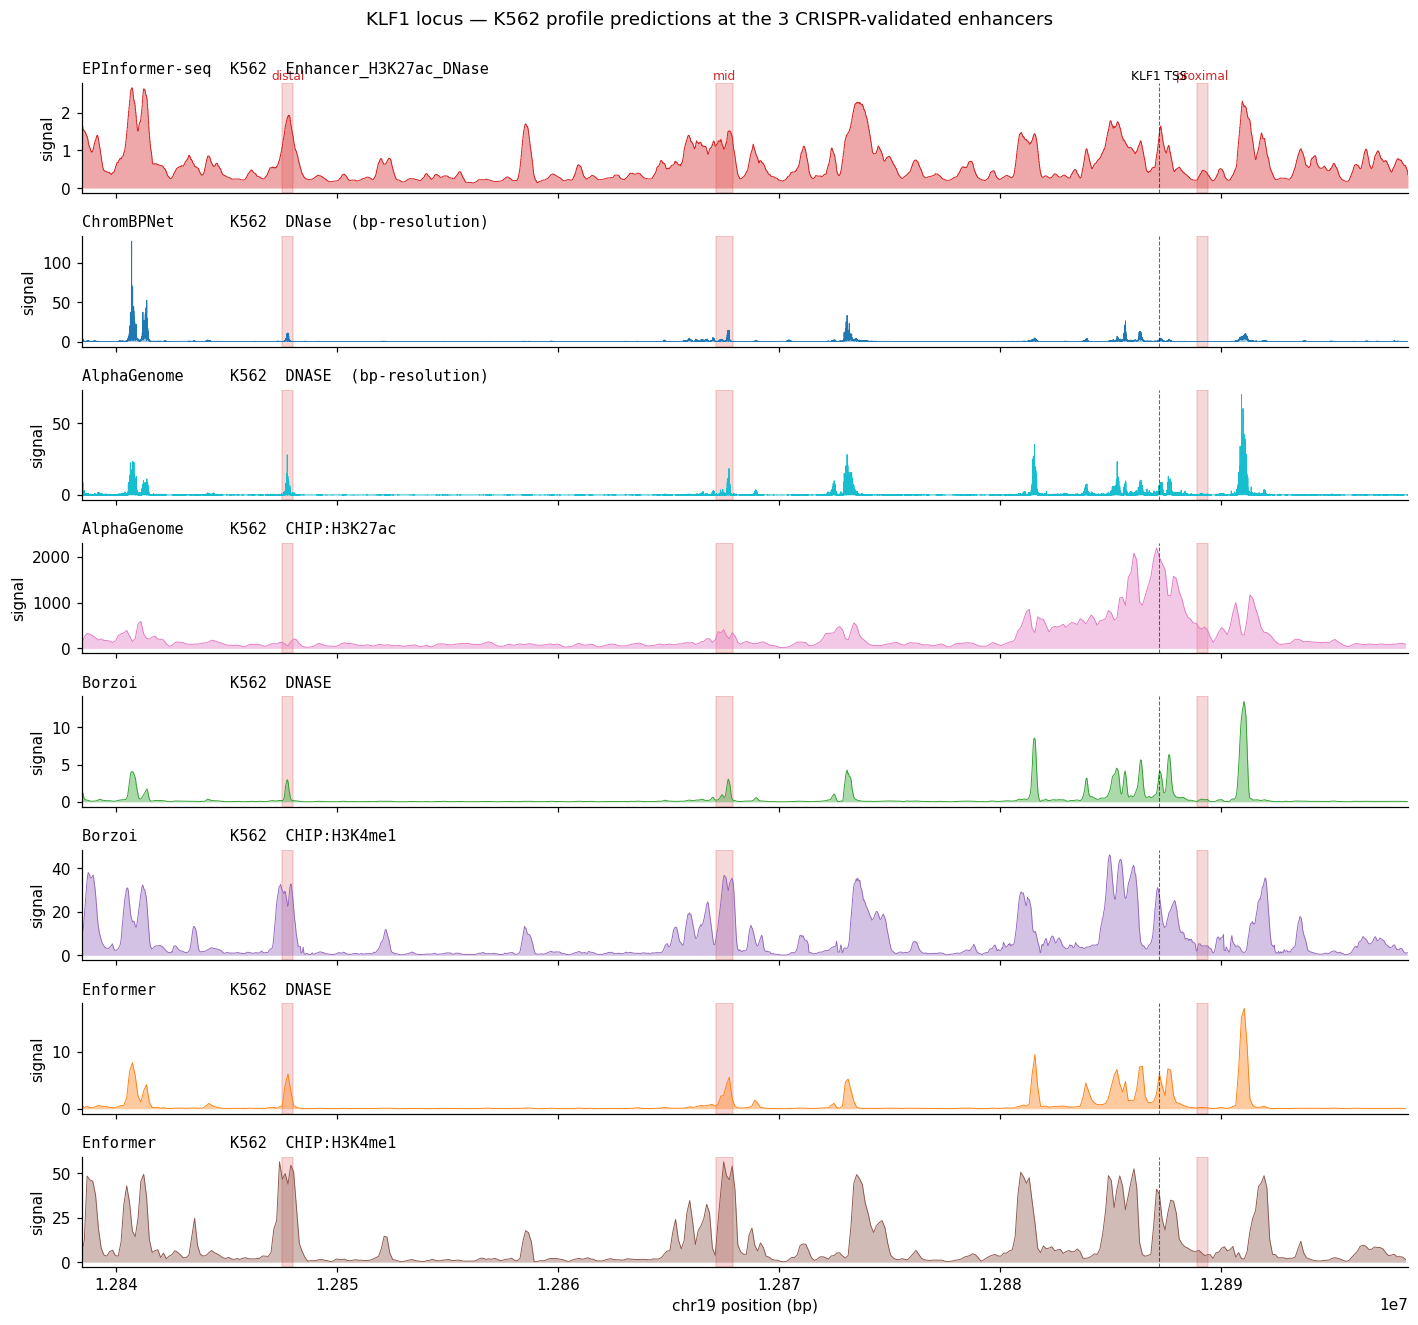

In [10]:
tracks_to_plot = [
    ('EPInformer-seq  K562  Enhancer_H3K27ac_DNase', epi_positions,  epi_profile,   '#d62728'),
    ('ChromBPNet      K562  DNase  (bp-resolution)', cbp_locus_x,    cbp_locus_profile, '#1f77b4'),
    ('AlphaGenome     K562  DNASE  (bp-resolution)', ag_dnase_x,     ag_dnase,      '#17becf'),
    ('AlphaGenome     K562  CHIP:H3K27ac',           ag_h3_x,        ag_h3,         '#e377c2'),
    ('Borzoi          K562  DNASE',                  borzoi_x,       borzoi_dnase,  '#2ca02c'),
    ('Borzoi          K562  CHIP:H3K4me1',           borzoi_x,       borzoi_h3k4m1, '#9467bd'),
    ('Enformer        K562  DNASE',                  enf_x,          enf_dnase,     '#ff7f0e'),
    ('Enformer        K562  CHIP:H3K4me1',           enf_x,          enf_h3k4m1,    '#8c564b'),
]

fig, axes = plt.subplots(len(tracks_to_plot), 1, figsize=(13, 1.5 * len(tracks_to_plot)),
                          sharex=True)
for ax, (title, x, y, color) in zip(axes, tracks_to_plot):
    ax.fill_between(x, y, color=color, alpha=0.4, linewidth=0)
    ax.plot(x, y, color=color, linewidth=0.6)
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    for _, row in klf1_pos.iterrows():
        ax.axvspan(row['chromStart'], row['chromEnd'], color='#d62728', alpha=0.18, zorder=0)
    ax.axvline(TSS, color='black', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(title, loc='left', fontsize=10, family='monospace')
    ax.set_ylabel('signal')

axes[-1].set_xlabel(f'{CHROM} position (bp)')
ax_top = axes[0]
for _, row in klf1_pos.iterrows():
    ax_top.annotate(row['label'], (row['midpoint'], ax_top.get_ylim()[1]),
                    ha='center', va='bottom', fontsize=8, color='#d62728')
ax_top.annotate('KLF1 TSS', (TSS, ax_top.get_ylim()[1]),
                ha='center', va='bottom', fontsize=8, color='black')
fig.suptitle('KLF1 locus — K562 profile predictions at the 3 CRISPR-validated enhancers',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

## § 8. Per-enhancer zoom — ±1 kb around each validated CRE

3 enhancers × 5 oracle/track columns. Enformer is omitted here because at 128-bp bins, ±1 kb is only ~16 bins, too coarse to inspect a single enhancer.

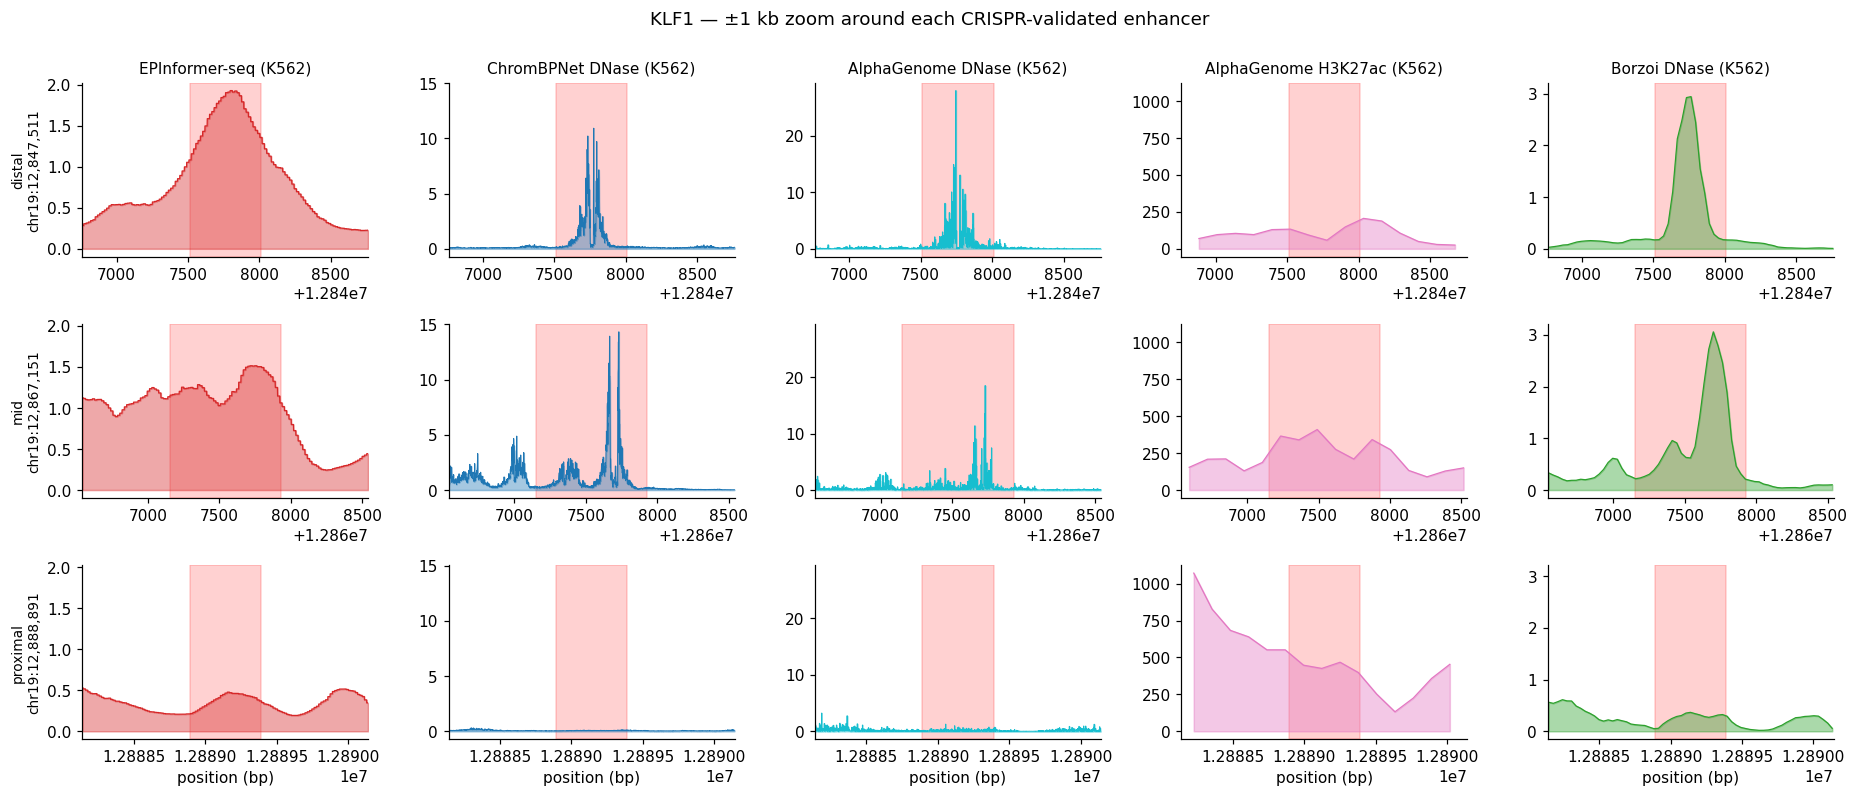

In [11]:
ZOOM_HALF = 1_000

fig, axes = plt.subplots(len(klf1_pos), 5, figsize=(17, 2.4 * len(klf1_pos)),
                          sharey='col')
col_titles = ['EPInformer-seq (K562)', 'ChromBPNet DNase (K562)',
              'AlphaGenome DNase (K562)', 'AlphaGenome H3K27ac (K562)',
              'Borzoi DNase (K562)']
col_colors = ['#d62728', '#1f77b4', '#17becf', '#e377c2', '#2ca02c']

for i, (_, row) in enumerate(klf1_pos.iterrows()):
    mid = int(row['midpoint'])
    zs, ze = mid - ZOOM_HALF, mid + ZOOM_HALF

    # col 0 — EPI sliding window (bp-resolution smoothed)
    m = (epi_positions >= zs) & (epi_positions < ze)
    ax = axes[i, 0]
    ax.fill_between(epi_positions[m], epi_profile[m], color=col_colors[0], alpha=0.4)
    ax.plot(epi_positions[m], epi_profile[m], color=col_colors[0], linewidth=0.8)

    # col 1 — ChromBPNet locus profile (bp-resolution)
    m = (cbp_locus_x >= zs) & (cbp_locus_x < ze)
    ax = axes[i, 1]
    ax.fill_between(cbp_locus_x[m], cbp_locus_profile[m], color=col_colors[1], alpha=0.4)
    ax.plot(cbp_locus_x[m], cbp_locus_profile[m], color=col_colors[1], linewidth=0.6)

    # col 2 — AlphaGenome DNase (bp-resolution)
    m = (ag_dnase_x >= zs) & (ag_dnase_x < ze)
    ax = axes[i, 2]
    ax.fill_between(ag_dnase_x[m], ag_dnase[m], color=col_colors[2], alpha=0.4)
    ax.plot(ag_dnase_x[m], ag_dnase[m], color=col_colors[2], linewidth=0.6)

    # col 3 — AlphaGenome H3K27ac (128-bp bins)
    m = (ag_h3_x >= zs) & (ag_h3_x < ze)
    ax = axes[i, 3]
    ax.fill_between(ag_h3_x[m], ag_h3[m], color=col_colors[3], alpha=0.4)
    ax.plot(ag_h3_x[m], ag_h3[m], color=col_colors[3], linewidth=0.8)

    # col 4 — Borzoi DNase (32-bp bins)
    m = (borzoi_x >= zs) & (borzoi_x < ze)
    ax = axes[i, 4]
    ax.fill_between(borzoi_x[m], borzoi_dnase[m], color=col_colors[4], alpha=0.4)
    ax.plot(borzoi_x[m], borzoi_dnase[m], color=col_colors[4], linewidth=0.8)

    for col in range(5):
        ax = axes[i, col]
        ax.axvspan(row['chromStart'], row['chromEnd'], color='red', alpha=0.18, zorder=0)
        ax.set_xlim(zs, ze)
        if col == 0:
            ax.set_ylabel(f"{row['label']}\n{CHROM}:{int(row['chromStart']):,}", fontsize=9)
        if i == 0:
            ax.set_title(col_titles[col], fontsize=10)
        if i == len(klf1_pos) - 1:
            ax.set_xlabel('position (bp)')

fig.suptitle('KLF1 — ±1 kb zoom around each CRISPR-validated enhancer', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

## § 9. Summary — per-enhancer peak-signal table

For each enhancer, take the maximum signal of each track within ±1 kb of the midpoint. This is the simplest cross-oracle apples-to-apples summary.

In [12]:
rows = []
for _, row in klf1_pos.iterrows():
    mid = int(row['midpoint']); zs, ze = mid - ZOOM_HALF, mid + ZOOM_HALF
    m_epi  = (epi_positions >= zs) & (epi_positions < ze)
    m_cbp  = (cbp_locus_x   >= zs) & (cbp_locus_x   < ze)
    m_ag_d = (ag_dnase_x    >= zs) & (ag_dnase_x    < ze)
    m_ag_h = (ag_h3_x       >= zs) & (ag_h3_x       < ze)
    m_b    = (borzoi_x      >= zs) & (borzoi_x      < ze)
    m_e    = (enf_x         >= zs) & (enf_x         < ze)
    rows.append({
        'label':                  row['label'],
        'chromStart':             int(row['chromStart']),
        'chromEnd':               int(row['chromEnd']),
        'EffectSize':             float(row['EffectSize']),
        'H3K27ac.RPM':            float(row['H3K27ac.RPM']),
        'EPI_peak':               float(epi_profile[m_epi].max()),
        'ChromBPNet_peak':        float(cbp_locus_profile[m_cbp].max()),
        'AlphaGenome_DNASE_peak':   float(ag_dnase[m_ag_d].max()),
        'AlphaGenome_H3K27ac_peak': float(ag_h3[m_ag_h].max()),
        'Borzoi_DNASE_peak':      float(borzoi_dnase[m_b].max()),
        'Borzoi_H3K4me1_peak':    float(borzoi_h3k4m1[m_b].max()),
        'Enformer_DNASE_peak':    float(enf_dnase[m_e].max()),
        'Enformer_H3K4me1_peak':  float(enf_h3k4m1[m_e].max()),
    })
summary = pd.DataFrame(rows)
summary

,label,chromStart,chromEnd,EffectSize,H3K27ac.RPM,EPI_peak,ChromBPNet_peak,AlphaGenome_DNASE_peak,AlphaGenome_H3K27ac_peak,Borzoi_DNASE_peak,Borzoi_H3K4me1_peak,Enformer_DNASE_peak,Enformer_H3K4me1_peak
0,distal,12847511,12848011,-0.057784,0.317648,1.928749,10.925719,28.000000,206.0,2.941778,32.739986,6.082299,56.285671
1,mid,12867151,12867931,-0.026087,2.818881,1.515190,14.331176,18.500000,410.0,3.058899,36.707619,5.526361,56.299889
2,proximal,12888891,12889391,-0.169294,1.707113,0.528762,0.321090,3.234375,1072.0,0.610623,10.946471,0.689311,10.227961


### Take-aways

1. **AlphaGenome's K562 H3K27ac ranks the three enhancers in the same order as the CRISPR effect** —
   proximal (peak 1072) > mid (410) > distal (206). Every other oracle/track in the panel ranks them in the *opposite* order (proximal lowest). AlphaGenome is the only oracle here with K562 H3K27ac in its training set, and this is the assay most aligned with the EPCrispr ground-truth label (which is also H3K27ac-driven).

2. **All DNase / H3K4me1 predictions put proximal *last*.** EPInformer-seq, ChromBPNet DNase, AlphaGenome DNase, Borzoi DNase, Borzoi H3K4me1, Enformer DNase, Enformer H3K4me1 — every accessibility / enhancer-mark prediction agrees that the proximal element has the *weakest* signal of the three. The fact that the proximal element has the *largest* CRISPR effect is consistent with H3K27ac (not DNase) being the more direct chromatin correlate of gene-regulation here.

3. **Caveat — proximal H3K27ac ≠ "this is an enhancer".** The proximal element sits ~2 kb from the TSS, well inside the typical KLF1 promoter H3K27ac plateau. AlphaGenome's H3K27ac peak there could partly reflect promoter-tail signal rather than enhancer-specific H3K27ac. This explains why a CRISPR perturbation at that location depresses KLF1 expression strongly (TSS-proximal disruption) but the DNase footprint is weak (promoter chromatin is broadly accessible but not a single sharp DNase peak).

4. **Cross-oracle agreement on DNase is strong.** ChromBPNet, AlphaGenome, Borzoi, Enformer all rank distal+mid above proximal on DNase — they're learning the same thing from the same training tracks. The differences are in resolution and amplitude, not in *where* the model thinks open chromatin lives.

5. **Resolution at the enhancer scale:**
   - bp-resolution: ChromBPNet, AlphaGenome DNase, EPInformer-seq (smoothed via overlap)
   - 32-bp bins: Borzoi
   - 128-bp bins: AlphaGenome H3K27ac, Enformer (too coarse to inspect a single 500-bp enhancer)

**Follow-up:** rank all 82 KLF1 candidate CREs by AlphaGenome H3K27ac peak signal vs. by every other oracle, and check whether AlphaGenome's H3K27ac uniquely surfaces the 3 CRISPR-validated positives — the per-enhancer ranking suggests it might.